In [1]:
from pathlib import Path

# Each eval dir is one timestamped output directory written by compute_metrics_junction_detection_nnunet_landmark.py
# containing metrics.csv and predictions_nnunet_landmark.csv. The per-case probability-map
# .npz/.json outputs (from nnunet_landmark_predict_from_files(..., save_probabilities=True))
# are copied alongside these into a subfolder of eval_out_dir named after the nnU-Net trainer,
EVAL_DIRS: list[Path] = [
    Path("/mnt/c/Users/juhe9/repos/MasterThesis/ForkSight/Data/nnunet_landmark_eval_output/Dataset011_nnUNetTrainerHeatmapAdaptiveWing/20260824_131404"),
    Path("/mnt/c/Users/juhe9/repos/MasterThesis/ForkSight/Data/nnunet_landmark_eval_output/Dataset011_nnUNetTrainerHeatmapAdaptiveWingFocal/20260825_100553"),
    Path("/mnt/c/Users/juhe9/repos/MasterThesis/ForkSight/Data/nnunet_landmark_eval_output/Dataset011_nnUNetTrainerHeatmapAdaptiveWingSoftSampling/20260825_103727"),
    Path("/mnt/c/Users/juhe9/repos/MasterThesis/ForkSight/Data/nnunet_landmark_eval_output/Dataset011_nnUNetTrainerHeatmapAdaptiveWingFocalSoftSampling/20260826_133002"),
    Path("/mnt/c/Users/juhe9/repos/MasterThesis/ForkSight/Data/nnunet_landmark_eval_output/Dataset012_nnUNetTrainerHeatmapAdaptiveWingFocalSoftSampling/20260826_150357"),
]

PLOT_PROBABILITY_MAPS = True

# Directory with the original (un-tiled) 4096x4096 PNG images, used as an underlay for the
# probability-map plots. File names here are NOT sanitized (may contain "_"/" "), unlike the
# .npz/.json case IDs written by the eval pipeline - a lookup is built at plot time by
# sanitizing each PNG's stem the same way (see _sanitize_case_id below), without renaming
# any files on disk.
ORIGINAL_IMAGES_DIR = Path(
    "/mnt/c/Users/juhe9/repos/MasterThesis/ForkSight/Data/RawData/junction_detection/images")

# relabeling_data.csv with the ground-truth junction annotations (x, y, label) for the
# evaluated test set - shared across all EVAL_DIRS runs, only used for the GT point overlay.
GT_ANNOTATIONS_CSV = Path(
    "/mnt/c/Users/juhe9/repos/MasterThesis/ForkSight/Data/RawData/junction_detection/relabeling_data.csv")

# Opacity of the underlying raw image, so the probability-map overlay on top of it stands
# out more clearly.
RAW_IMAGE_ALPHA = 0.3

# Opacity of the red/blue probability-map overlay on top of the underlying image
# (per-pixel alpha is additionally scaled by each pixel's own (gamma-boosted) probability,
# so near-zero-probability regions stay transparent regardless of this value).
PROB_MAP_OVERLAY_ALPHA = 0.9

# Gamma correction (< 1) applied to each probability value before it's used for color/alpha,
# i.e. prob ** PROB_MAP_GAMMA. Values below 1 boost mid/low probabilities so weaker clusters
# and peaks stand out more clearly instead of fading into white; 1.0 = no boost (linear).
PROB_MAP_GAMMA = 0.5

# In addition to the actual (threshold=0.5) detected points, also run peak detection at
# these lower thresholds and print (not plot as points) any extra clusters only found there -
# i.e. landmarks that "almost" cleared the real detection threshold.
PROB_MAP_LOWER_THRESHOLDS = (0.4, 0.3)

In [2]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# repo root, so the pipeline's own GT-loading logic can be reused instead of duplicated here
sys.path.append(os.path.abspath(".."))
from Evaluation.compute_metrics_junction_detection import _load_gt_annotations

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

In [3]:
def bold_best(df: pd.DataFrame, lower_is_better_cols: set[str] | None = None):
    """Return a Styler that bolds the best value in each column."""
    lower_is_better_cols = lower_is_better_cols or set()

    def _apply(s: pd.Series) -> list[str]:
        numeric = pd.to_numeric(s, errors="coerce")
        want_min = s.name in lower_is_better_cols
        best = numeric.min() if want_min else numeric.max()
        return [
            "font-weight: bold" if (not np.isnan(v) and v == best) else ""
            for v in numeric
        ]

    float_cols = df.select_dtypes(include="number").columns
    fmt = {c: "{:.4f}" for c in float_cols}
    return (
        df.style
        .apply(_apply, axis=0)
        .format(fmt, na_rep="\u2013")
        .set_table_styles([{"selector": "th, td", "props": "font-family: inherit; font-size: inherit;"}])
    )


def horizontal_bar_groups(df: pd.DataFrame, col_groups: list[tuple],
                          lower_is_better: set[str] | None = None,
                          col_rename: dict | None = None,
                          ylim: tuple | None = (0, 1.18),
                          cols_per_row: int | None = None,
                          suptitle: str = "") -> None:
    """Bar chart grid, one subplot per column group.  Legend is placed above the figure.

    Parameters
    ----------
    ylim         : (ymin, ymax) or None to auto-scale each subplot independently.
    cols_per_row : max subplots per row; None keeps all groups in a single row.
    """
    from matplotlib.gridspec import GridSpec

    lower_is_better = lower_is_better or set()
    col_rename = col_rename or {}

    filtered_groups = [
        [c for c in group if c in df.columns]
        for group in col_groups
    ]
    filtered_groups = [g for g in filtered_groups if g]
    if not filtered_groups:
        print("  (no columns available for bar chart)")
        return

    model_labels = [str(n) for n in df.index]
    total_cols = sum(len(g) for g in filtered_groups)
    colors = plt.cm.tab10(np.linspace(0, 0.9, len(df)))

    # Split groups into rows
    cpr = cols_per_row or len(filtered_groups)
    row_chunks = [filtered_groups[i:i + cpr]
                  for i in range(0, len(filtered_groups), cpr)]
    n_rows = len(row_chunks)

    ncol = min(len(df), 4)
    n_legend_rows = (len(df) + ncol - 1) // ncol
    top_gap = 0.05 * n_legend_rows + (0.07 if suptitle else 0.03)
    subplot_top = 1.2 - top_gap

    row_height = max(4, len(df) * 0.5 + 1.5)
    fig_width = max(10, 2.0 * total_cols)
    fig_height = row_height * n_rows

    fig = plt.figure(figsize=(fig_width, fig_height))
    outer_gs = GridSpec(n_rows, 1, figure=fig, hspace=0.45)

    first_handles, first_labels = None, None

    for row_idx, chunk in enumerate(row_chunks):
        width_ratios = [len(g) for g in chunk]
        inner_gs = outer_gs[row_idx].subgridspec(
            1, len(chunk), width_ratios=width_ratios, wspace=0.3)

        for ci, cols in enumerate(chunk):
            ax = fig.add_subplot(inner_gs[0, ci])
            x = np.arange(len(cols))
            width = 0.8 / max(len(df), 1)

            bars_by_col: dict[int, list[tuple]] = {
                k: [] for k in range(len(cols))}

            for i, (model, row) in enumerate(df.iterrows()):
                vals = [float(row.get(c, np.nan)) for c in cols]
                offset = (i - len(df) / 2 + 0.5) * width
                rects = ax.bar(x + offset, vals, width * 0.9,
                               label=model_labels[i], color=colors[i])
                for k, (rect, val) in enumerate(zip(rects, vals)):
                    bars_by_col[k].append((val, rect))

            if first_handles is None:
                first_handles, first_labels = ax.get_legend_handles_labels()

            # Annotation offset relative to data range
            all_vals = [v for entries in bars_by_col.values()
                        for v, _ in entries if not np.isnan(v)]
            y_range = (max(all_vals) - min(all_vals)
                       ) if len(all_vals) >= 2 else 1.0
            ann_offset = y_range * 0.025

            for k, col in enumerate(cols):
                entries = [(v, r)
                           for v, r in bars_by_col[k] if not np.isnan(v)]
                if not entries:
                    continue
                want_min = col in lower_is_better
                best_val, best_rect = (min(entries, key=lambda t: t[0]) if want_min
                                       else max(entries, key=lambda t: t[0]))
                bar_x = best_rect.get_x() + best_rect.get_width() / 2
                ax.text(bar_x, best_rect.get_height() + ann_offset,
                        f"{best_val:.3f}",
                        ha="center", va="bottom", fontsize=7, fontweight="bold")

            tick_labels = [col_rename.get(
                c, c).replace(" ", "\n") for c in cols]
            ax.set_xticks(x)
            ax.set_xticklabels(tick_labels, fontsize=8)
            ax.grid(axis="y", linestyle="--", alpha=0.4)

            if ylim is not None:
                ax.set_ylim(*ylim)
            else:
                if all_vals:
                    ax.set_ylim(0, max(all_vals) + y_range * 0.15)

    plt.tight_layout(rect=[0, 0, 1, subplot_top])
    fig.legend(
        first_handles, first_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, subplot_top),
        ncol=ncol,
        fontsize=8,
        framealpha=0.8,
    )
    if suptitle:
        fig.suptitle(suptitle, fontsize=12, y=0.99)

    plt.show()
    plt.close()

## Load Metrics

In [4]:
# Each metrics.csv is a single row (one model/run per compute_metrics_junction_detection_nnunet_landmark.py
# invocation), so we stack one row per (label, eval_out_dir) pair into a single dataframe indexed by label.

def _get_dataset_trainer_from_eval_dir(eval_dir: Path) -> str:
    return eval_dir.parent.name

_rows = {}
for eval_dir in EVAL_DIRS:
    dataset_trainer = _get_dataset_trainer_from_eval_dir(eval_dir)
    csv_path = eval_dir / "metrics.csv"
    if not csv_path.is_file():
        raise FileNotFoundError(f"metrics.csv not found for '{dataset_trainer}' in {eval_dir}")
    df_one = pd.read_csv(csv_path)
    if len(df_one) != 1:
        raise ValueError(f"Expected a single-row metrics.csv for '{dataset_trainer}', got {len(df_one)} rows")
    _rows[dataset_trainer] = df_one.iloc[0]

df_jd = pd.DataFrame(_rows).T
df_jd.index.name = "Model"
print(f"Loaded junction detection metrics for {len(df_jd)} model(s):")

for eval_dir in EVAL_DIRS:
    dataset_trainer = _get_dataset_trainer_from_eval_dir(eval_dir)
    print(f"  {dataset_trainer}: {eval_dir}")

Loaded junction detection metrics for 5 model(s):
  Dataset011_nnUNetTrainerHeatmapAdaptiveWing: /mnt/c/Users/juhe9/repos/MasterThesis/ForkSight/Data/nnunet_landmark_eval_output/Dataset011_nnUNetTrainerHeatmapAdaptiveWing/20260824_131404
  Dataset011_nnUNetTrainerHeatmapAdaptiveWingFocal: /mnt/c/Users/juhe9/repos/MasterThesis/ForkSight/Data/nnunet_landmark_eval_output/Dataset011_nnUNetTrainerHeatmapAdaptiveWingFocal/20260825_100553
  Dataset011_nnUNetTrainerHeatmapAdaptiveWingSoftSampling: /mnt/c/Users/juhe9/repos/MasterThesis/ForkSight/Data/nnunet_landmark_eval_output/Dataset011_nnUNetTrainerHeatmapAdaptiveWingSoftSampling/20260825_103727
  Dataset011_nnUNetTrainerHeatmapAdaptiveWingFocalSoftSampling: /mnt/c/Users/juhe9/repos/MasterThesis/ForkSight/Data/nnunet_landmark_eval_output/Dataset011_nnUNetTrainerHeatmapAdaptiveWingFocalSoftSampling/20260826_133002
  Dataset012_nnUNetTrainerHeatmapAdaptiveWingFocalSoftSampling: /mnt/c/Users/juhe9/repos/MasterThesis/ForkSight/Data/nnunet_landma

In [5]:
# Ground truth junction counts (informative only - not asserted equal, since different
# runs being compared could in principle have evaluated different test sets)
print("Ground truth junctions in test set per model:")
for datset_trainer in df_jd.index:
    n3 = int(df_jd.loc[datset_trainer, "gt_3way_total"])
    n4 = int(df_jd.loc[datset_trainer, "gt_4way_total"])
    print(f"  {datset_trainer}: 3-way={n3}  4-way={n4}  total={n3 + n4}")

Ground truth junctions in test set per model:
  Dataset011_nnUNetTrainerHeatmapAdaptiveWing: 3-way=45  4-way=77  total=122
  Dataset011_nnUNetTrainerHeatmapAdaptiveWingFocal: 3-way=45  4-way=77  total=122
  Dataset011_nnUNetTrainerHeatmapAdaptiveWingSoftSampling: 3-way=45  4-way=77  total=122
  Dataset011_nnUNetTrainerHeatmapAdaptiveWingFocalSoftSampling: 3-way=45  4-way=77  total=122
  Dataset012_nnUNetTrainerHeatmapAdaptiveWingFocalSoftSampling: 3-way=45  4-way=77  total=122


In [6]:
# Derive a micro-averaged "joint" combined metric (both classes summed) from the
# per-class counts already in the CSV.
def _prf(tp, fp, fn):
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    return prec, rec, f1

tp = df_jd["class_tp_3way"] + df_jd["class_tp_4way"]
fp = df_jd["class_fp_3way"] + df_jd["class_fp_4way"]
fn = df_jd["class_fn_3way"] + df_jd["class_fn_4way"]
prf = [_prf(tp.iloc[i], fp.iloc[i], fn.iloc[i]) for i in range(len(df_jd))]
df_jd["class_tp_combined"]        = tp.values
df_jd["class_fp_combined"]        = fp.values
df_jd["class_fn_combined"]        = fn.values
df_jd["class_precision_combined"] = [p for p, _, _ in prf]
df_jd["class_recall_combined"]    = [r for _, r, _ in prf]
df_jd["class_f1_combined"]        = [f for _, _, f in prf]

In [7]:
# Column groups - all higher-is-better
_JD_LOCALISATION      = ["precision_loc", "recall_loc", "f1_loc"]
_JD_DETECTION_RECALL  = ["detection_recall_3way", "detection_recall_4way"]
_JD_TYPE_OVERALL      = ["type_accuracy"]
_JD_CLASS_COMBINED    = ["class_precision_combined", "class_recall_combined", "class_f1_combined"]
_JD_CLASS_3WAY        = ["class_precision_3way", "class_recall_3way", "class_f1_3way"]
_JD_CLASS_4WAY        = ["class_precision_4way", "class_recall_4way", "class_f1_4way"]

_JD_DISPLAY_COLS = (
    _JD_LOCALISATION + _JD_DETECTION_RECALL + _JD_TYPE_OVERALL
    + _JD_CLASS_COMBINED + _JD_CLASS_3WAY + _JD_CLASS_4WAY
)

_DISPLAY_RENAME = {
    "precision_loc":            "Precision (loc)",
    "recall_loc":               "Recall (loc)",
    "f1_loc":                   "F1 (loc)",
    "detection_recall_3way":    "Det. Recall 3-way",
    "detection_recall_4way":    "Det. Recall 4-way",
    "type_accuracy":            "Type Accuracy",
    "class_precision_combined": "Precision (joint)",
    "class_recall_combined":    "Recall (joint)",
    "class_f1_combined":        "F1 (joint)",
    "class_precision_3way":     "Precision 3-way",
    "class_recall_3way":        "Recall 3-way",
    "class_f1_3way":            "F1 3-way",
    "class_precision_4way":     "Precision 4-way",
    "class_recall_4way":        "Recall 4-way",
    "class_f1_4way":            "F1 4-way",
}


def _jd_table(df: pd.DataFrame, title: str) -> None:
    cols_in_df = [c for c in _JD_DISPLAY_COLS if c in df.columns]
    if not cols_in_df:
        print("No junction detection metric columns found.")
        return
    display(HTML(f"<h4>{title}</h4>"))
    sub = df[cols_in_df].copy()
    sub.columns = [_DISPLAY_RENAME.get(c, c) for c in cols_in_df]
    display(bold_best(sub))

**Precision / Recall / F1 (loc):** class-agnostic; a prediction is a TP if it falls within the pixel threshold of *any* GT junction, regardless of type.
**Det. Recall 3-way / 4-way:** per-GT-class localisation recall - of all GT junctions of that type, what fraction were spatially matched by *any* prediction (regardless of predicted type). Also shown in the confusion matrix title.
**Type Accuracy:** among spatially-matched TPs only - fraction whose type label (3-way / 4-way) matches GT.
**Precision / Recall / F1 (joint):** micro-averaged over both classes; a prediction is a TP for class $c$ only if it is both correctly localised *and* correctly labelled - equivalent to summing the per-class TP/FP/FN counts before computing the metrics.
**Precision / Recall / F1 3-way & 4-way:** same joint criterion, broken out per class. FP and FN include both spurious/missed detections and type misclassifications (see confusion matrices below).

Predictions come from `"Normal Fork"` heatmap peaks (matched to 3-way GT) and combined `"Reversed Fork / Crossing"` heatmap peaks (matched to 4-way GT) - see `compute_metrics_junction_detection_nnunet_landmark.py`.

### Junction Detection Metrics

In [8]:
_jd_table(df_jd, title="nnU-Net Landmark (Heatmap Regression) - Junction Detection")

,Precision (loc),Recall (loc),F1 (loc),Det. Recall 3-way,Det. Recall 4-way,Type Accuracy,Precision (joint),Recall (joint),F1 (joint),Precision 3-way,Recall 3-way,F1 3-way,Precision 4-way,Recall 4-way,F1 4-way
Model,,,,,,,,,,,,,,,
Dataset011_nnUNetTrainerHeatmapAdaptiveWing,0.5172,0.1230,0.1987,0.2000,0.0779,0.8000,0.4138,0.0984,0.1589,0.6000,0.2000,0.3000,0.2143,0.0390,0.0659
Dataset011_nnUNetTrainerHeatmapAdaptiveWingFocal,0.7059,0.0984,0.1727,0.1111,0.0909,1.0000,0.7059,0.0984,0.1727,0.7143,0.1111,0.1923,0.7000,0.0909,0.1609
Dataset011_nnUNetTrainerHeatmapAdaptiveWingSoftSampling,0.6800,0.1393,0.2313,0.1778,0.1169,1.0000,0.6800,0.1393,0.2313,0.8000,0.1778,0.2909,0.6000,0.1169,0.1957
Dataset011_nnUNetTrainerHeatmapAdaptiveWingFocalSoftSampling,0.7692,0.0820,0.1481,0.0889,0.0779,1.0000,0.7692,0.0820,0.1481,0.6667,0.0889,0.1569,0.8571,0.0779,0.1429
Dataset012_nnUNetTrainerHeatmapAdaptiveWingFocalSoftSampling,0.7778,0.2295,0.3544,0.4444,0.1039,1.0000,0.7778,0.2295,0.3544,0.8333,0.4444,0.5797,0.6667,0.1039,0.1798


### Junction Detection Bar Charts

In [9]:
#horizontal_bar_groups(
#    df_jd,
#    col_groups=[
#        tuple(_JD_LOCALISATION),
#        tuple(_JD_DETECTION_RECALL),
#        tuple(_JD_TYPE_OVERALL + _JD_CLASS_COMBINED),
#        tuple(_JD_CLASS_3WAY),
#        tuple(_JD_CLASS_4WAY),
#    ],
#    col_rename=_DISPLAY_RENAME,
#    cols_per_row=2,
#    suptitle="nnU-Net Landmark - Junction Detection",
#)

### Confusion Matrices

Rows = GT outcome (3-way / 4-way / no GT). Columns = prediction outcome (pred 3-way / pred 4-way / not found). Cell % is row-normalised.

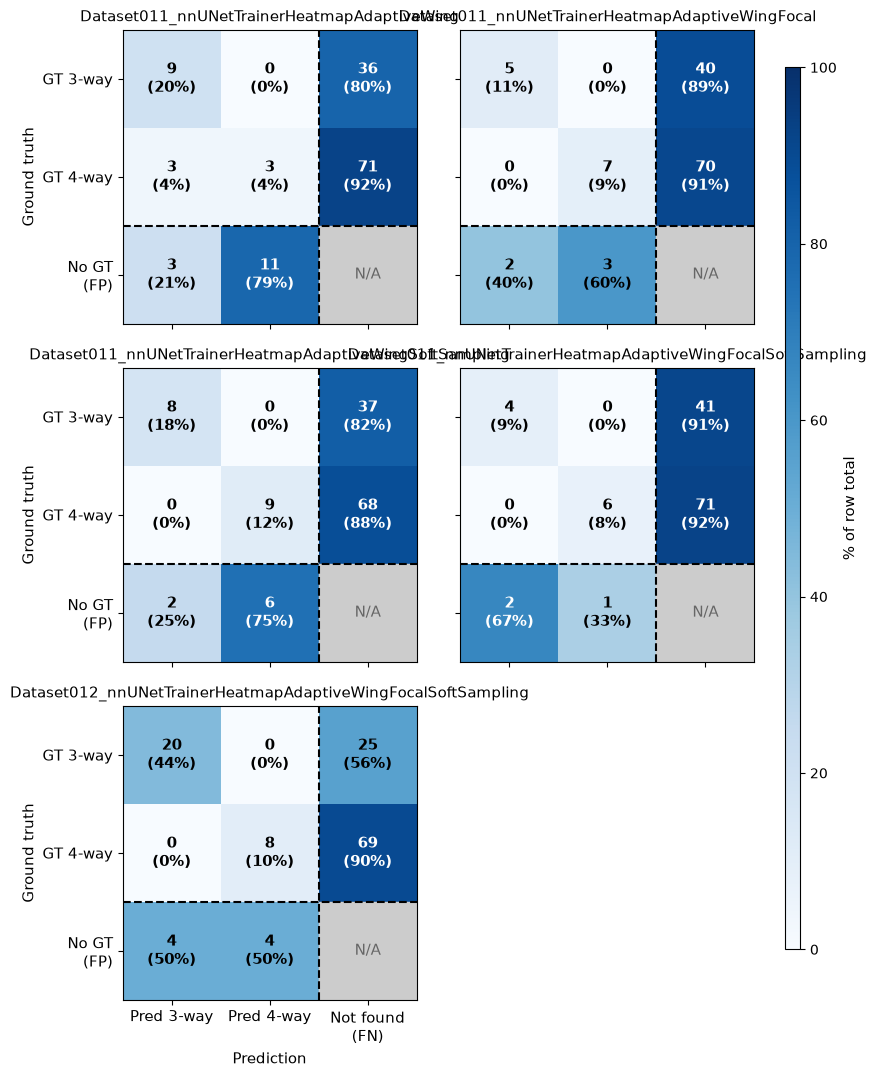

In [10]:
_CM_FONT = 11
_CM_COL_LABELS = ["Pred 3-way", "Pred 4-way", "Not found\n(FN)"]
_CM_ROW_LABELS = ["GT 3-way", "GT 4-way", "No GT\n(FP)"]


def _plot_cm_from_row(ax, row, title, show_x_labels=True, show_y_labels=True):
    cm = np.array([
        [row["cm_gt3_pred3"], row["cm_gt3_pred4"], row["fn_3way"]],
        [row["cm_gt4_pred3"], row["cm_gt4_pred4"], row["fn_4way"]],
        [row["fp_3way"],      row["fp_4way"],      float("nan")],
    ], dtype=float)

    row_totals = np.array([
        row["gt_3way_total"],
        row["gt_4way_total"],
        row["fp_3way"] + row["fp_4way"],
    ], dtype=float)

    with np.errstate(divide="ignore", invalid="ignore"):
        cm_pct = np.where(row_totals[:, None] > 0,
                          100.0 * cm / row_totals[:, None],
                          np.nan)

    masked = np.ma.masked_invalid(cm_pct)
    im = ax.imshow(masked, cmap="Blues", vmin=0, vmax=100, aspect="equal")

    ax.add_patch(plt.Rectangle((1.5, 1.5), 1, 1, color="#cccccc", zorder=2))
    ax.text(2, 2, "N/A", ha="center", va="center",
            fontsize=_CM_FONT, color="#666666", zorder=3)

    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(_CM_COL_LABELS if show_x_labels else [""] * 3, fontsize=_CM_FONT)
    ax.set_yticklabels(_CM_ROW_LABELS if show_y_labels else [""] * 3, fontsize=_CM_FONT)
    if show_x_labels:
        ax.set_xlabel("Prediction", fontsize=_CM_FONT)
    if show_y_labels:
        ax.set_ylabel("Ground truth", fontsize=_CM_FONT)

    for r in range(3):
        for c in range(3):
            if r == 2 and c == 2:
                continue
            val = cm[r, c]
            if np.isnan(val):
                continue
            pct = cm_pct[r, c]
            pct_str = f"\n({pct:.0f}%)" if not np.isnan(pct) else ""
            text_color = "white" if (not np.isnan(pct) and pct > 60) else "black"
            ax.text(c, r, f"{int(val)}{pct_str}",
                    ha="center", va="center",
                    fontsize=_CM_FONT, color=text_color, fontweight="bold", zorder=4)

    ax.axhline(1.5, color="black", linewidth=1.5, linestyle="--")
    ax.axvline(1.5, color="black", linewidth=1.5, linestyle="--")
    ax.set_title(title, fontsize=_CM_FONT)
    return im


_cols = 2
_rows = (len(df_jd) + _cols - 1) // _cols
fig, axes = plt.subplots(_rows, _cols, figsize=(4.2 * _cols, 4.2 * _rows), squeeze=False)

im = None
for i, dataset_trainer in enumerate(df_jd.index):
    r, channel = i // _cols, i % _cols
    ax = axes[r][channel]
    im = _plot_cm_from_row(
        ax, df_jd.loc[dataset_trainer], str(dataset_trainer),
        show_x_labels=(r == _rows - 1),
        show_y_labels=(channel == 0),
    )

for ax in axes.flat[len(df_jd):]:
    ax.set_visible(False)

plt.subplots_adjust(wspace=0.05, hspace=0.15, right=0.91)

cbar_ax = fig.add_axes([0.93, 0.15, 0.018, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("% of row total", fontsize=_CM_FONT)
cbar.ax.tick_params(labelsize=_CM_FONT - 1)

plt.show()
plt.close()

## Predicted Probability Maps

Renders each per-case heatmap-regression probability map (from the `.npz` files saved by `nnunet_landmark_predict_from_files(..., save_probabilities=True)`) as a single image per case: the original 4096x4096 raw image (dimmed to `RAW_IMAGE_ALPHA`), with the "Normal Fork" (3-way) probability overlaid white&rarr;red and the "Reversed Fork / Crossing" (4-way) probability overlaid white&rarr;blue - both semi-transparent (fully transparent where probability is ~0) and gamma-boosted (`PROB_MAP_GAMMA`) so clusters and peaks stand out more clearly. Predicted and ground-truth junction points are plotted as open circles on top (lime = 3-way, orange = 4-way; small solid circles = prediction, larger dashed circles = GT, so neither obstructs the probability blobs much), with a legend. Runs once per entry in `EVAL_DIRS`; plots are saved to `eval_dir / "plot" / trainer`.

For every case, also detects (but does not plot) landmark clusters that would only appear at the lower thresholds in `PROB_MAP_LOWER_THRESHOLDS` (e.g. 0.4, 0.3) - these are printed as text, to surface near-miss detections that didn't clear the real (0.5) threshold.

Only runs if `PLOT_PROBABILITY_MAPS` is set to `True` in the config cell above.

In [11]:
import gc
import time

try:
    import psutil
    _HAS_PSUTIL = True
except ImportError:
    _HAS_PSUTIL = False
    print("psutil not installed - the memory-headroom safeguard below will be a no-op "
          "(only the fixed inter-plot sleep still applies). `pip install psutil` to enable it.")

if PLOT_PROBABILITY_MAPS:
    import matplotlib.patches as mpatches
    from PIL import Image
    from skimage.feature import peak_local_max

    # --- crash-safeguard knobs --------------------------------------------------------
    # Each probability map is 4096x4096; the colored overlays built below are full-resolution
    # float32 RGBA arrays (~256MB *per channel*) that matplotlib then holds a reference to for
    # the lifetime of the Figure. Figures/Axes/Artists form internal reference cycles (canvas,
    # callback registries, etc.) that plain refcounting does NOT release - only a real
    # gc.collect() does. Without forcing that every iteration (the original code only did it
    # every 20 images), a burst of unreclaimed figures/arrays can exceed a small WSL2 VM's fixed
    # memory budget (this machine has ~7.4GB total) and crash the whole VM instead of just this
    # kernel. These knobs trade a bit of speed for headroom; tune PLOT_SLEEP_SECONDS /
    # PLOT_MIN_AVAILABLE_GB down if this turns out to be overly conservative.
    PLOT_SLEEP_SECONDS = 0.3              # heuristic pause after every plot - throttles alloc/I/O bursts
    PLOT_GC_EVERY_N = 1                   # force a full gc.collect() every N images (1 = every image)
    PLOT_MIN_AVAILABLE_GB = 1.0           # abort rather than risk a crash below this much free RAM
    PLOT_LOW_MEM_RETRIES = 5
    PLOT_LOW_MEM_RETRY_SLEEP_SECONDS = 3.0

    def _available_gb() -> float | None:
        if not _HAS_PSUTIL:
            return None
        return psutil.virtual_memory().available / (1024 ** 3)

    def _wait_for_memory_headroom(context: str) -> bool:
        """Blocks (with retries + forced gc) until free memory clears PLOT_MIN_AVAILABLE_GB.
        Returns False (caller should abort) if it's still critically low afterwards. No-op
        (always True) if psutil isn't available to check with."""
        avail = _available_gb()
        if avail is None or avail >= PLOT_MIN_AVAILABLE_GB:
            return True
        for attempt in range(1, PLOT_LOW_MEM_RETRIES + 1):
            print(f"  [memory guard] only {avail:.2f} GB free before {context} "
                  f"(need {PLOT_MIN_AVAILABLE_GB:.1f} GB) - forcing gc + pausing "
                  f"(attempt {attempt}/{PLOT_LOW_MEM_RETRIES})...")
            plt.close("all")
            gc.collect()
            time.sleep(PLOT_LOW_MEM_RETRY_SLEEP_SECONDS)
            avail = _available_gb()
            if avail >= PLOT_MIN_AVAILABLE_GB:
                return True
        print(f"  [memory guard] still only {avail:.2f} GB free after {PLOT_LOW_MEM_RETRIES} "
              f"retries - aborting remaining plots to avoid a WSL crash. Free up host RAM "
              f"(or restart the kernel) and re-run this cell; already-saved plots are skipped "
              f"on the next pass.")
        return False

    _MIN_DISTANCE = 3      # matches NNUNET_LANDMARK_DEFAULT_MIN_DISTANCE
    _DEFAULT_THRESHOLD = 0.5  # matches NNUNET_LANDMARK_DEFAULT_THRESHOLD
    _PRED_MARKER_RADIUS = 45
    _GT_MARKER_RADIUS = 55

    # Channel order matches create_nnunet_heatmap_dataset.get_label_mapping(combine_reversed_crossing=True):
    # 0 = background/combined (skipped), 1 = Normal Fork, 2 = Reversed Fork / Crossing
    _PROB_MAP_CHANNELS = {
        1: ("3-way", "Normal Fork (3-way)", (1.0, 0.0, 0.0)),   # red
        2: ("4-way", "Reversed Fork / Crossing (4-way)", (0.0, 0.0, 1.0)),  # blue
    }

    # Predictions: small solid-outline circles. GT: larger dashed-outline circles (so GT
    # markers don't obstruct the probability blobs the way filled/crossed markers would).
    _MARKER_STYLE = {
        ("pred", "3-way"): dict(color="lime", linestyle="-", radius=_PRED_MARKER_RADIUS, label="Pred 3-way", linewidth=0.5),
        ("pred", "4-way"): dict(color="orange", linestyle="-", radius=_PRED_MARKER_RADIUS, label="Pred 4-way", linewidth=0.5),
        ("gt", "3-way"): dict(color="lime", linestyle="--", radius=_GT_MARKER_RADIUS, label="GT 3-way", linewidth=0.5),
        ("gt", "4-way"): dict(color="orange", linestyle="--", radius=_GT_MARKER_RADIUS, label="GT 4-way", linewidth=0.5),
    }

    def _sanitize_case_id(img_name: str) -> str:
        # mirrors compute_metrics_junction_detection_nnunet_landmark._sanitize_case_id
        return img_name.replace("_", "-").replace(" ", "-")

    def _build_sanitized_png_lookup(image_dir: Path) -> dict[str, Path]:
        """Maps sanitized-case-id -> original PNG path, without renaming anything on disk."""
        lookup: dict[str, Path] = {}
        for p in sorted(Path(image_dir).glob("*.png")):
            key = _sanitize_case_id(p.stem)
            if key in lookup:
                raise ValueError(
                    f"Sanitized PNG name collision: '{p.name}' and '{lookup[key].name}' "
                    f"both sanitize to '{key}' - cannot disambiguate which is case '{key}'.")
            lookup[key] = p
        return lookup

    def _colored_prob_overlay(prob_map: np.ndarray, color_rgb: tuple, alpha_scale: float,
                              gamma: float = 1.0) -> np.ndarray:
        """White-to-`color_rgb` gradient in RGB, with per-pixel alpha = prob**gamma * alpha_scale,
        so near-zero-probability pixels stay transparent instead of hazing over the whole image,
        and (for gamma < 1) mid/low probabilities are boosted so weaker clusters stand out more."""
        color = np.asarray(color_rgb, dtype=np.float32)
        prob = np.clip(prob_map, 0.0, 1.0).astype(np.float32) ** gamma
        rgb = 1.0 - prob[..., None] * (1.0 - color)
        alpha = prob * alpha_scale
        return np.dstack([rgb, alpha])

    def _peak_coords(channel_map: np.ndarray, threshold: float) -> dict[tuple[int, int], float]:
        coords = peak_local_max(
            channel_map, min_distance=_MIN_DISTANCE, threshold_abs=threshold)
        return {(int(x), int(y)): float(channel_map[y, x]) for y, x in coords}

    png_lookup = _build_sanitized_png_lookup(ORIGINAL_IMAGES_DIR)
    print(f"Found {len(png_lookup)} original image(s) in {ORIGINAL_IMAGES_DIR}")

    gt_by_image = _load_gt_annotations(GT_ANNOTATIONS_CSV)
    print(
        f"Loaded GT annotations for {len(gt_by_image)} image(s) from {GT_ANNOTATIONS_CSV}")

    _aborted = False

    for eval_dir in EVAL_DIRS:
        if _aborted:
            break

        dataset_trainer = _get_dataset_trainer_from_eval_dir(eval_dir)
        prob_map_plot_out_dir = eval_dir / "plot"

        _npz_paths = sorted(eval_dir.glob("*.npz"))
        if not _npz_paths:
            print(f"[{dataset_trainer}] No .npz probability maps found in {eval_dir}")
            continue

        pred_csv_path = eval_dir / "predictions_nnunet_landmark.csv"
        if not pred_csv_path.is_file():
            raise FileNotFoundError(
                f"predictions_nnunet_landmark.csv not found for '{dataset_trainer}' in {eval_dir}")
        pred_df = pd.read_csv(pred_csv_path)

        prob_map_plot_out_dir.mkdir(parents=True, exist_ok=True)

        n_plotted = 0
        near_miss_report: list[tuple[str, str, float, dict]] = []

        for idx, npz_path in enumerate(_npz_paths):
            case_id = npz_path.stem
            out_path = prob_map_plot_out_dir / f"{case_id}.png"

            if out_path.exists():
                # print(f"plot {out_path.name} already exists, skipping")
                continue

            if not _wait_for_memory_headroom(f"case '{case_id}'"):
                _aborted = True
                break

            fig = None
            raw_img = None
            probabilities = None
            try:
                probabilities = np.load(
                    npz_path)["probabilities"].astype(np.float32)
                # revert_heatmap_to_original_geometry keeps a singleton z-axis for 2D configs
                # (shape (C, 1, H, W)); drop it so each channel is a plain (H, W) image.
                if probabilities.ndim == 4 and probabilities.shape[1] == 1:
                    probabilities = probabilities[:, 0]

                # --- near-miss cluster detection at lower thresholds (text only, no plotting) ---
                for channel, (_, channel_label, _) in _PROB_MAP_CHANNELS.items():
                    channel_map = probabilities[channel]
                    prev_coords = set(_peak_coords(
                        channel_map, _DEFAULT_THRESHOLD))
                    for lower_thresh in PROB_MAP_LOWER_THRESHOLDS:
                        peaks_lower = _peak_coords(channel_map, lower_thresh)
                        new_coords = {xy: score for xy, score in peaks_lower.items()
                                      if xy not in prev_coords}
                        if new_coords:
                            near_miss_report.append(
                                (case_id, channel_label, lower_thresh, new_coords))
                        prev_coords |= set(peaks_lower)

                # --- probability-map + points plot ---
                png_path = png_lookup.get(case_id)
                if png_path is None:
                    print(f"[{dataset_trainer}] {case_id}: no matching PNG found in "
                          f"{ORIGINAL_IMAGES_DIR}, skipping plot")
                    continue
                # the un-sanitized stem, as used in predictions_nnunet_landmark.csv's "image"
                # column and relabeling_data.csv's "image" column
                stem = png_path.stem

                # `with` closes the PIL file handle (and its internal decode buffers)
                # as soon as the array copy is made, instead of leaving it open for GC.
                with Image.open(png_path) as _img:
                    raw_img = np.array(_img)
                orig_h, orig_w = raw_img.shape[:2]
                extent = [0, orig_w, orig_h, 0]

                fig, ax = plt.subplots(figsize=(10, 10))
                ax.imshow(raw_img, cmap="gray" if raw_img.ndim == 2 else None,
                          extent=extent, alpha=RAW_IMAGE_ALPHA)
                for channel, (_, _, color) in _PROB_MAP_CHANNELS.items():
                    overlay = _colored_prob_overlay(
                        probabilities[channel], color, PROB_MAP_OVERLAY_ALPHA,
                        gamma=PROB_MAP_GAMMA)
                    ax.imshow(overlay, extent=extent)
                    del overlay  # matplotlib now holds the reference it needs; drop ours

                plotted_labels: set[str] = set()

                def _scatter(points, kind):
                    for x, y, jtype in points:
                        style = _MARKER_STYLE[(kind, jtype)]
                        label = style["label"] if style["label"] not in plotted_labels else None
                        plotted_labels.add(style["label"])
                        circle = mpatches.Circle(
                            (x, y), radius=style["radius"], fill=False,
                            edgecolor=style["color"], linestyle=style["linestyle"],
                            linewidth=2.0, alpha=0.95, label=label, zorder=5)
                        ax.add_patch(circle)

                pred_rows = pred_df[pred_df["image"] == stem]
                _scatter([(r.x, r.y, r.pred_type)
                         for r in pred_rows.itertuples()], "pred")
                _scatter([(a["x"], a["y"], a["type"])
                         for a in gt_by_image.get(stem, [])], "gt")

                ax.set_xlim(0, orig_w)
                ax.set_ylim(orig_h, 0)
                ax.set_aspect("equal")
                ax.axis("off")

                handles, labels = ax.get_legend_handles_labels()
                handles += [
                    mpatches.Patch(color=(1.0, 0.0, 0.0), alpha=0.5,
                                   label="Normal Fork (3-way) prob."),
                    mpatches.Patch(color=(0.0, 0.0, 1.0), alpha=0.5,
                                   label="Reversed Fork / Crossing (4-way) prob."),
                ]
                labels += ["Normal Fork (3-way) prob.",
                           "Reversed Fork / Crossing (4-way) prob."]
                ax.legend(handles, labels, loc="upper right",
                          fontsize=8, framealpha=0.85)

                ax.set_title(f"{dataset_trainer} - {case_id}", fontsize=11)
                plt.tight_layout()
                fig.savefig(out_path, dpi=150, bbox_inches="tight")
                n_plotted += 1
            finally:
                # Always close/free, even if an exception was raised above - a figure or a
                # large array leaked on error is exactly the kind of thing that compounds
                # into an OOM crash over a long EVAL_DIRS run.
                if fig is not None:
                    fig.clf()
                    plt.close(fig)
                del raw_img, probabilities, fig
                if idx % PLOT_GC_EVERY_N == 0:
                    gc.collect()

            # heuristic throttle: give the OS a moment to actually reclaim the freed
            # memory (and settle any pending I/O to the eval_dir, often on /mnt/c) before
            # the next iteration's allocation burst starts.
            time.sleep(PLOT_SLEEP_SECONDS)

        plt.close("all")
        gc.collect()

        print(
            f"[{dataset_trainer}] Saved {n_plotted} probability map plot(s) to {prob_map_plot_out_dir}")

        if near_miss_report:
            print(f"[{dataset_trainer}] Near-miss clusters (below threshold={_DEFAULT_THRESHOLD}, "
                  f"min_distance={_MIN_DISTANCE}):")
            for case_id, channel_label, thr, coords in near_miss_report:
                pts = ", ".join(
                    f"(x={x}, y={y}, score={s:.3f})" for (x, y), s in coords.items())
                print(
                    f"    {case_id} | {channel_label} | threshold={thr}: {pts}")
        else:
            print(f"[{dataset_trainer}] No near-miss clusters found at thresholds "
                  f"{PROB_MAP_LOWER_THRESHOLDS}.")

    if _aborted:
        print("\nAborted early due to low memory - free up RAM (or restart the kernel) and "
              "re-run this cell to resume; already-saved plots will be skipped.")
else:
    print("PLOT_PROBABILITY_MAPS is False - skipping probability map plots.")

Found 100 original image(s) in /mnt/c/Users/juhe9/repos/MasterThesis/ForkSight/Data/RawData/junction_detection/images
Loaded GT annotations for 100 image(s) from /mnt/c/Users/juhe9/repos/MasterThesis/ForkSight/Data/RawData/junction_detection/relabeling_data.csv
[Dataset011_nnUNetTrainerHeatmapAdaptiveWing] Saved 0 probability map plot(s) to /mnt/c/Users/juhe9/repos/MasterThesis/ForkSight/Data/nnunet_landmark_eval_output/Dataset011_nnUNetTrainerHeatmapAdaptiveWing/20260824_131404/plot
[Dataset011_nnUNetTrainerHeatmapAdaptiveWing] No near-miss clusters found at thresholds (0.4, 0.3).
[Dataset011_nnUNetTrainerHeatmapAdaptiveWingFocal] Saved 0 probability map plot(s) to /mnt/c/Users/juhe9/repos/MasterThesis/ForkSight/Data/nnunet_landmark_eval_output/Dataset011_nnUNetTrainerHeatmapAdaptiveWingFocal/20260825_100553/plot
[Dataset011_nnUNetTrainerHeatmapAdaptiveWingFocal] No near-miss clusters found at thresholds (0.4, 0.3).
[Dataset011_nnUNetTrainerHeatmapAdaptiveWingSoftSampling] Saved 0 pro